# ¡Hola Alejandro1!

Mi nombre es Sofia Arboleda, estaré ayudándote a revisar este proyecto para que quede en su mejor versión.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. Esto es útil para que te acostumbres a un escenario laboral. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión.

Encontrarás mis comentarios más abajo - **por favor, no los muevas, no los modifiques ni los borres**.

¿Cómo funciona esta revisión? Leeré atentamente tu código y te señalaré tus fortalezas y aquellas cosas que podemos mejorar. Los comentarios aparecerán de esta forma:


<div class="alert alert-block alert-success">
<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si todo está perfecto y no se requieren cambios en el código.
</div>


<div class="alert alert-block alert-warning">
<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta. Se aceptan uno o dos comentarios de este tipo en el borrador, pero si hay más, deberás hacer las correcciones.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si definitivamente hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma si algo no queda claro (copia este código en una celda markdown):

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>

Hola, muchas gracias por tus comentarios y la revisión.        
</div>

**Es un gusto acompañarte en este proceso, ¡empecemos!**

# Proyecto: Análisis de ventas de videojuegos

Este proyecto tiene como objetivo identificar patrones que determinen si un videojuego tiene éxito o no, utilizando datos históricos de ventas, reseñas y características de juegos disponibles hasta 2016. El análisis permitirá detectar proyectos prometedores y planificar campañas publicitarias efectivas para la tienda online Ice.

Pasos del proyecto:

#### Paso 1: Exploración inicial de los datos

###### Carga y revisión general del dataset
###### Identificación de la estructura y características principales

#### Paso 2: Preparación de los datos

###### Normalización de nombres de columnas
###### Conversión de tipos de datos
###### Tratamiento de valores ausentes y duplicados
###### Cálculo de ventas totales por juego

#### Paso 3: Análisis exploratorio de datos

###### Análisis de tendencias temporales
###### Estudio de plataformas y géneros más exitosos
###### Identificación de patrones de ventas por región
#### Paso 4: Análisis de perfiles de usuario por región

###### Comparación de preferencias entre regiones (NA, EU, JP)
###### Análisis de plataformas y géneros populares por mercado

#### Paso 5: Pruebas de hipótesis estadísticas

###### Validación de diferencias significativas entre grupos
###### Conclusiones basadas en evidencia estadística

### Paso 1:
Cargar el archivo y explorar la información general

##### 1.1 Importar librerias necesarias.

In [1]:
import pandas as pd 
import numpy as np
import math as mt
import matplotlib.pyplot as plt
from scipy import stats

##### 1.2 Leer el archivo y ver informacion general.

In [2]:
df=pd.read_csv('/datasets/games.csv')

In [3]:
display(df.head())
print(df.info())
print(df.describe())

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None
       Year_of_Release      NA_sales      EU_sales      JP_sales  \
count     16446.000000  16715.000000  16715.000000  16715.000000   
mean       2006.484616      0.263377      0.145060      0.077617   
std           5.877050      0.81

### Paso 2:
Preparacion de los datos.

##### 2.1 Nombre de las columnas

In [4]:
df.columns = df.columns.str.lower()
print(df.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


Se transformaron los nombres de las columnas a minúsculas para facilitar su manipulación y mantener consistencia en el código.

##### 2.2 Tipos de datos por variable

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [6]:
df['year_of_release'] = pd.to_numeric(df['year_of_release'], errors='coerce')
df['year_of_release'] = df['year_of_release'].astype('Int64')
df['critic_score']=pd.to_numeric(df['critic_score'],errors='coerce')
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')
print(df.dtypes)

name                object
platform            object
year_of_release      Int64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score         float64
rating              object
dtype: object


##### 2.3 Valores ausentes

In [7]:
null_c=df[df['critic_score'].isna()]
null_u=df[df['user_score'].isna()]
null_r=df[df['rating'].isna()]

In [8]:
print(null_c)
print(null_u)
print(null_r)

                                name platform  year_of_release         genre  \
1                  Super Mario Bros.      NES             1985      Platform   
4           Pokemon Red/Pokemon Blue       GB             1996  Role-Playing   
5                             Tetris       GB             1989        Puzzle   
9                          Duck Hunt      NES             1984       Shooter   
10                        Nintendogs       DS             2005    Simulation   
...                              ...      ...              ...           ...   
16710  Samurai Warriors: Sanada Maru      PS3             2016        Action   
16711               LMA Manager 2007     X360             2006        Sports   
16712        Haitaka no Psychedelica      PSV             2016     Adventure   
16713               Spirits & Spells      GBA             2003      Platform   
16714            Winning Post 8 2016      PSV             2016    Simulation   

       na_sales  eu_sales  jp_sales  ot

In [9]:
print(df.isna().sum())
print(df.isna().mean().sort_values(ascending=False) * 100)

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64
user_score         54.591684
critic_score       51.319174
rating             40.478612
year_of_release     1.609333
name                0.011965
genre               0.011965
platform            0.000000
na_sales            0.000000
eu_sales            0.000000
jp_sales            0.000000
other_sales         0.000000
dtype: float64


Los valores ausentes se dejaron en blanco en las columnas `critic_score`, `user_score` y `rating`, ya que no existe una forma confiable de imputarlos sin introducir sesgos.

Posibles razones de ausencia:
- Algunos juegos no recibieron suficientes reseñas de usuarios o críticos.
- Algunas clasificaciones ESRB no fueron registradas.
- En `user_score`, el valor `TBD` indica que la puntuación aún no estaba determinada.

Por esta razón, `TBD` se reemplazó por `NaN`.

##### 2.4 Buscar duplicados

In [10]:
print('Duplicados completos:', df.duplicated().sum())
print('Duplicados por juego/plataforma/año:', 
      df.duplicated(subset=['name', 'platform', 'year_of_release']).sum())
duplicados = df[df.duplicated(subset=['name', 'platform', 'year_of_release'], keep=False)]
print(f'Número de filas duplicadas: {len(duplicados)}')

Duplicados completos: 0
Duplicados por juego/plataforma/año: 2
Número de filas duplicadas: 4


##### 2.5 Crear columna de ventas totales

In [11]:
df['total_sales'] = (
    df['na_sales'] +
    df['eu_sales'] +
    df['jp_sales'] +
    df['other_sales']
)

display(df[['name', 'platform', 'total_sales']].head())

,name,platform,total_sales
0,Wii Sports,Wii,82.54
1,Super Mario Bros.,NES,40.24
2,Mario Kart Wii,Wii,35.52
3,Wii Sports Resort,Wii,32.77
4,Pokemon Red/Pokemon Blue,GB,31.38


Se creó la columna `total_sales`, que representa la suma de las ventas en Norteamérica, Europa, Japón y otras regiones.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Hiciste un buen uso de los metodos para estandarizar los encabezados del dataset, además la conversión de tipo y el reemplazo del valor atipico 'tbt' por nulos me parece muy apropiado para permitir el manejo de los datos. Soluciones válidas en este caso para manejar los nulos serían:

- Introducir un valor irreal que depende de la columna y su significado (-1, -999999, etc.).
- Dejar los huecos sin cambios.

Tu idea de mantener las columnas con estos valores nulos está muy bien justificada, en especial considerando los porcentajes que representan en los casos de las columnas `critic_score` y `user_score`, donde se generarían sesgos significativos con reemplazo de valores nulos. 

</div></div>
</div>

### Paso 3: Analisis de datos

##### 3.1 Numero de juegos lanzados por año 

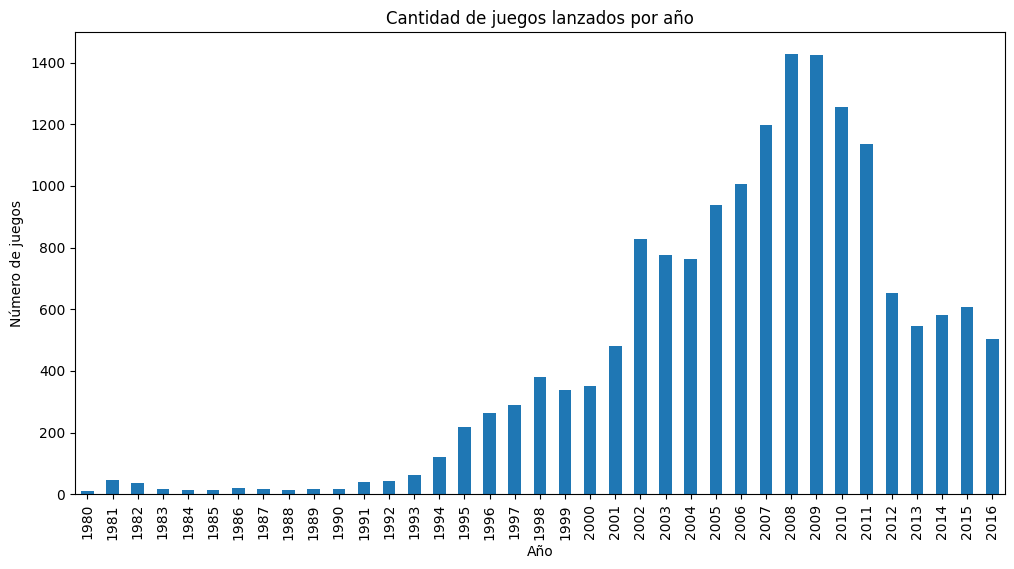

In [12]:
games_per_year = df['year_of_release'].value_counts().sort_index()

plt.figure(figsize=(12,6))
games_per_year.plot(kind='bar')
plt.title('Cantidad de juegos lanzados por año')
plt.xlabel('Año')
plt.ylabel('Número de juegos')
plt.show()

Se observa cómo la cantidad de juegos lanzados varía a lo largo del tiempo. Los primeros años presentan menos registros, posiblemente porque la industria era más pequeña o porque la base de datos es menos completa. A partir de cierto período los datos son más representativos, teniendo una alta concentracion de lanzamientos entre los años 2002 y 2012, teniendo su pico en los años 2008 y 2009.lo que ha ido disminuyendo hasta 2016.

Esto puede indicar una tendencia bajista en cuando a proyeccion de lanzamiento de videojuegos, lo que se puede deber por falta de inversion, menos rentabilidad, cierre de empresas de videojuegos, etc.

##### 3.2 Ventas entre plataformas

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
Name: total_sales, dtype: float64

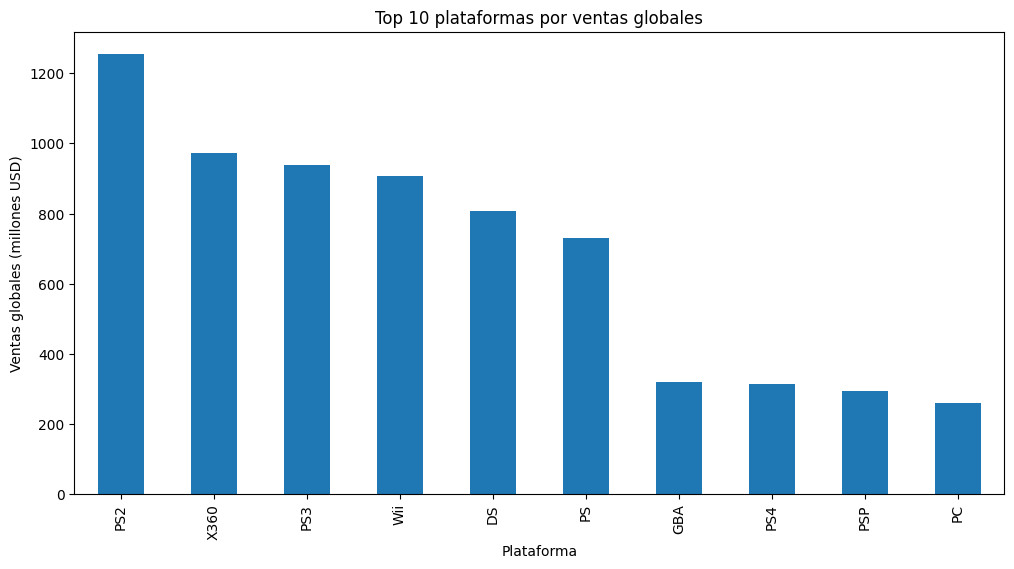

In [13]:
platform_sales = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
display(platform_sales.head(10))

plt.figure(figsize=(12,6))
platform_sales.head(10).plot(kind='bar')
plt.title('Top 10 plataformas por ventas globales')
plt.xlabel('Plataforma')
plt.ylabel('Ventas globales (millones USD)')
plt.show()

Se puede observar que la plataforma que mas ventas globales genera es la PS2, seguida de la X360 y la PS3, mientras que las plataformas menos vendidas globalmente son pc, psp y ps4.

#### 3.3 Evolución anual de las plataformas más grandes

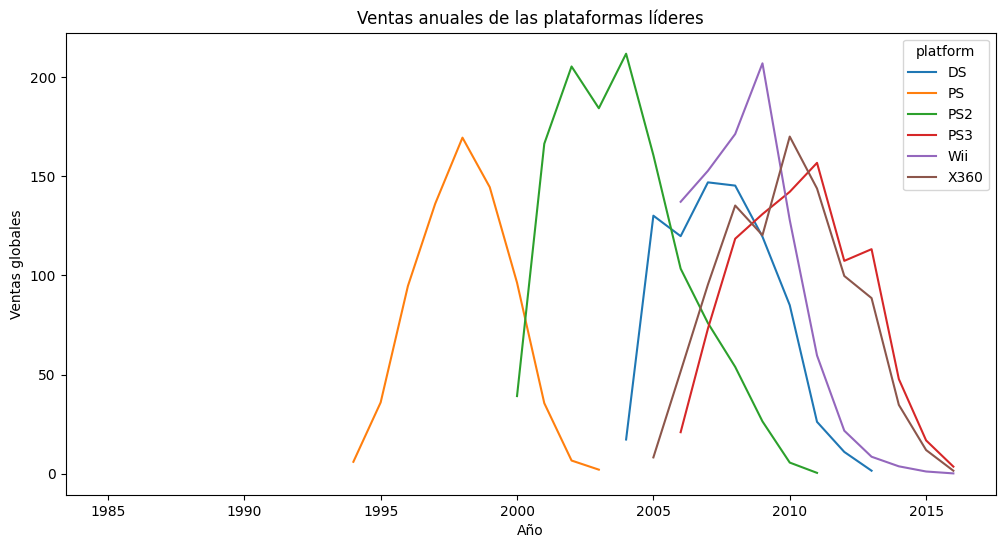

In [14]:
top_platforms = platform_sales.head(6).index

platform_year_sales = (
    df[df['platform'].isin(top_platforms)]
    .pivot_table(index='year_of_release', columns='platform', values='total_sales', aggfunc='sum')
)

platform_year_sales.plot(figsize=(12,6))
plt.title('Ventas anuales de las plataformas líderes')
plt.xlabel('Año')
plt.ylabel('Ventas globales')
plt.show()

El lanzamiento de la consola mas vendida coincide con el pico de lanzamientos de videojuegos, lo que indica una posible relacion entre estas dos variables, En adicion a ello se logra apreciar que las consolas tienen un tiempo de vida limitado con un pico para luego un posterior declive, siendo la mas consistente la PS2.

<div class="alert alert-block alert-success"> 
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Genial! Muy buen trabajo con las ventas por plataforma y los juegos lanzados por año. Además, se puede reconocer estos picos de diferentes plataformas de video juegos en las épocas datadas. Buen trabajo!
</div>

#### 3.4 Elegir periodo relevante para analisis

In [15]:
recent_df = df[df['year_of_release'] >= 2013].copy()
print(recent_df['year_of_release'].min(), recent_df['year_of_release'].max())

2013 2016


Se escogio el periodo entre los años 2013 y 2016, ya que los mismos son los mas recientes para predecir el 2017 y se encuentran estables, sin mostrar tendencias alcistas ni bajistas claras que puedan crear un sesgo a la hora de predecir el año 2017.

#### 3.5 Plataformas líderes, en crecimiento o en caída

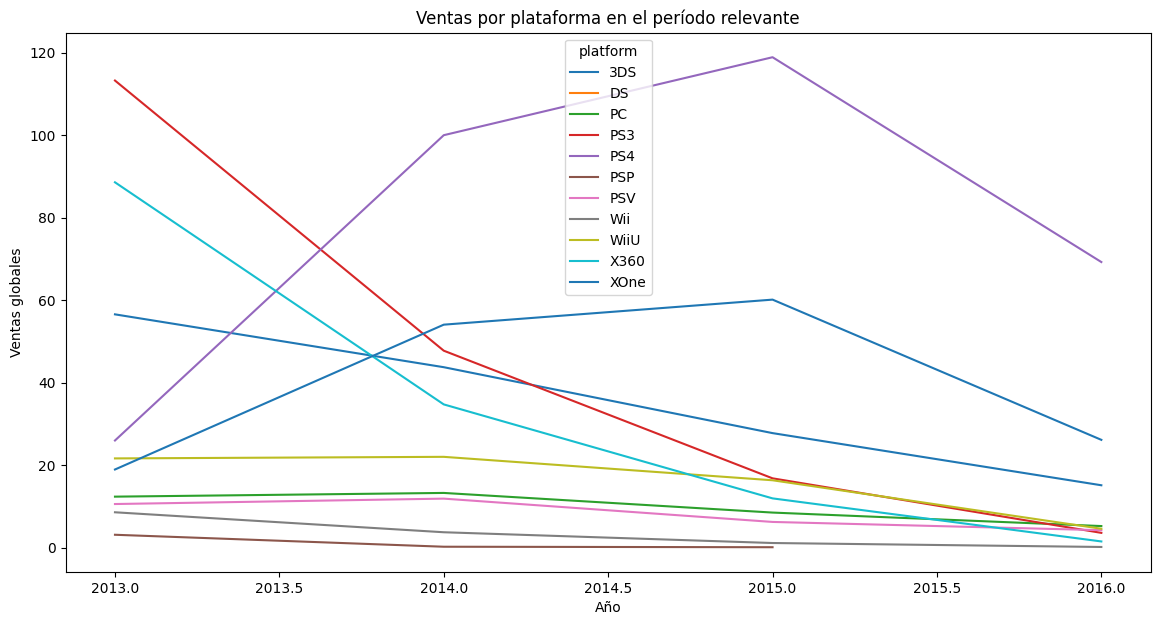

In [16]:
recent_platform_sales = (
    recent_df.groupby(['year_of_release', 'platform'])['total_sales']
    .sum()
    .reset_index()
)

pivot_recent = recent_platform_sales.pivot(index='year_of_release', columns='platform', values='total_sales')
pivot_recent.plot(figsize=(14,7))
plt.title('Ventas por plataforma en el período relevante')
plt.xlabel('Año')
plt.ylabel('Ventas globales')
plt.show()

En el gráfico se logra apreciar una fuerte tendencia bajista en todas las consolas, especialmente desde el año 2015, siendo las que aún siguen activas en el mercado tres: la XOne, la PS4 y la 3DS.

Esto puede indicar que son las plataformas más recientes y que están llegando al cierre de su ciclo de vida en el mercado. Por lo tanto, es en estas consolas que se deben enfocar los desarrolladores, pero no en grandes cantidades, ya que probablemente se realice el lanzamiento de nuevas consolas pronto, en unos 2-3 años. Se tiene que aprovechar al máximo este pequeño intervalo

#### 3.6. Diagrama de caja por plataforma

<Figure size 1400x700 with 0 Axes>

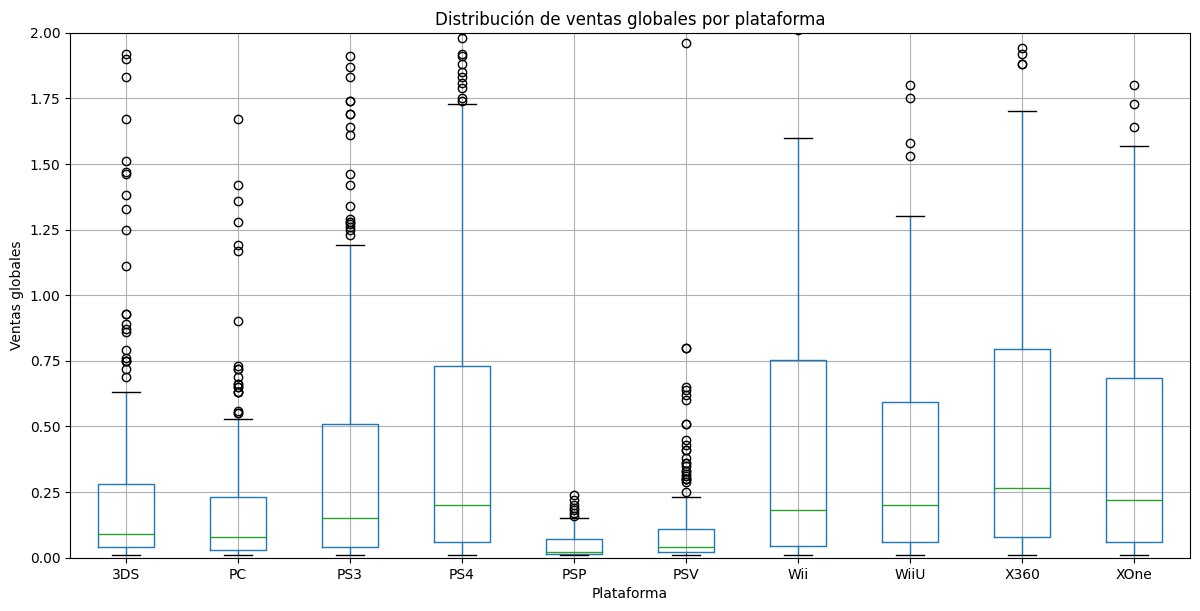

In [17]:
top_recent_platforms = (
    recent_df.groupby('platform')['total_sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

plt.figure(figsize=(14,7))
recent_df[recent_df['platform'].isin(top_recent_platforms)].boxplot(
    column='total_sales',
    by='platform',
    figsize=(14,7)
)
plt.title('Distribución de ventas globales por plataforma')
plt.suptitle('')
plt.xlabel('Plataforma')
plt.ylabel('Ventas globales')
plt.ylim(0, 2)  # puedes quitar esto si quieres ver todos los outliers
plt.show()

El diagrama de caja permite comparar la distribución de ventas entre plataformas. Se observan diferencias en la mediana, la dispersión y la presencia de valores atípicos. En varias plataformas, la mayoría de los juegos venden relativamente poco, mientras que unos pocos títulos concentran ventas muy altas.

<div class="alert alert-block alert-success"> 
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Tu elección de rango temporal para el analisis es muy valida, en efecto, un periodo no mayor de 5 años es la mejor eleccion en este caso dada la alta variabilidad del comportamiento de las tecnologias emergentes en la ultima decada. 
Excelente trabajo con el analisis por plataforma para el periodo elegido. El grafico de cajas está correcto, buen trabajo con los limites en el eje Y que permitan observar mejor la distribucion por plataforma sin darle tanta importancia a los outliers.
</div>

#### 3.7. Reseñas vs ventas en una plataforma popular

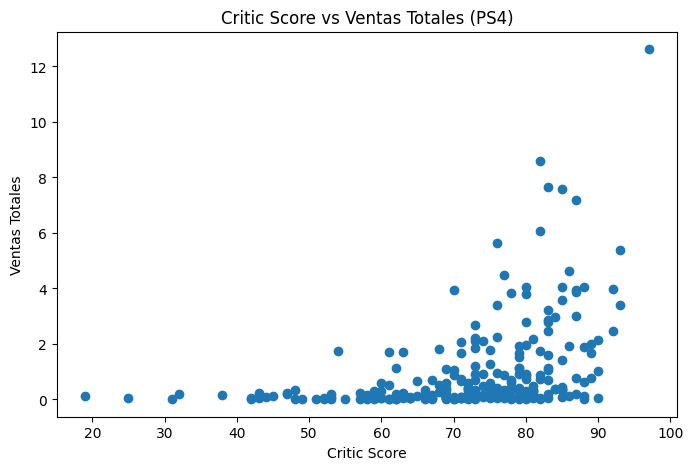

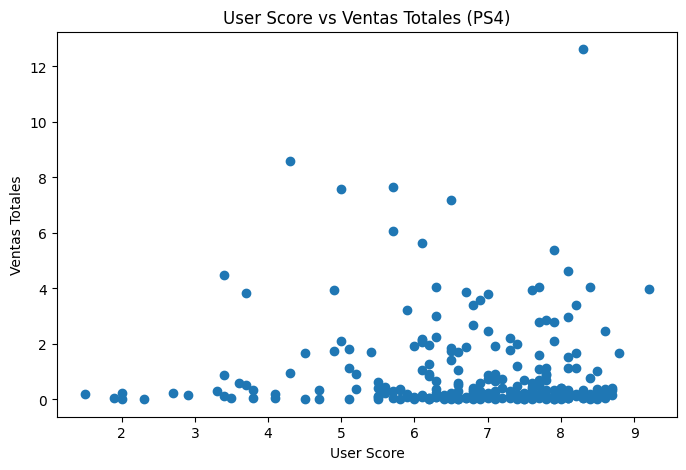

Correlación critic_score vs ventas: 0.40589480145836687
Correlación user_score vs ventas: -0.03362497596528878


In [18]:
platform_selected = 'PS4'

platform_data = recent_df[
    (recent_df['platform'] == platform_selected) &
    (~recent_df['critic_score'].isna()) &
    (~recent_df['user_score'].isna())
]

# Dispersión critic_score vs total_sales
plt.figure(figsize=(8,5))
plt.scatter(platform_data['critic_score'], platform_data['total_sales'])
plt.title(f'Critic Score vs Ventas Totales ({platform_selected})')
plt.xlabel('Critic Score')
plt.ylabel('Ventas Totales')
plt.show()

# Dispersión user_score vs total_sales
plt.figure(figsize=(8,5))
plt.scatter(platform_data['user_score'], platform_data['total_sales'])
plt.title(f'User Score vs Ventas Totales ({platform_selected})')
plt.xlabel('User Score')
plt.ylabel('Ventas Totales')
plt.show()

# Correlaciones
critic_corr = platform_data['critic_score'].corr(platform_data['total_sales'])
user_corr = platform_data['user_score'].corr(platform_data['total_sales'])

print('Correlación critic_score vs ventas:', critic_corr)
print('Correlación user_score vs ventas:', user_corr)

En el diagrama de dispersión se observa una fuerte correlación positiva entre el puntaje de la crítica y las ventas totales de la consola (0.406), mientras que el puntaje de los usuarios no tiene correlación con las ventas (-0.034). Esto sugiere que el puntaje de la crítica puede ser un buen indicador de ventas y que entre mayor sea el puntaje de la crítica mayores serán las ventas totales. Esta diferencia se debe a cómo los usuarios y la crítica califican: la crítica tiene estándares determinados y objetivos mientras que los usuarios lo hacen mediante subjetividad, lo que significa que los usuarios no pueden determinar realmente qué tan bueno es el producto desde una perspectiva comercial. Por tanto, las puntuaciones de críticos son un mejor predictor del éxito en ventas que las opiniones de usuarios.


<div class="alert alert-block alert-success"> 
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Exacto! Tu calculo y presentacion de las correlaciones entre ventas y reseñas es muy adecuado, como mencionas, se observa una mayor correlación entre ventas y reseñas de críticos que con las reseñas de usuarios. 

#### 3.8. Comparar ventas de los mismos juegos en otras plataformas

In [19]:
ps4_games = recent_df[recent_df['platform'] == platform_selected][['name', 'total_sales']]
same_games = recent_df[recent_df['name'].isin(ps4_games['name'])]

comparison = same_games.pivot_table(
    index='name',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
)

display(comparison.head(10))

platform,3DS,DS,PC,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne
name,,,,,,,,,,,
7 Days to Die,NaN,NaN,NaN,NaN,0.14,NaN,NaN,NaN,NaN,NaN,0.05
Adventure Time: Finn & Jake Investigations,0.09,NaN,NaN,0.08,0.10,NaN,NaN,NaN,0.05,0.09,0.05
Aegis of Earth: Protonovus Assault,NaN,NaN,NaN,0.02,0.02,NaN,0.03,NaN,NaN,NaN,NaN
Agatha Christie's The ABC Murders,NaN,NaN,NaN,NaN,0.02,NaN,NaN,NaN,NaN,NaN,0.01
Akiba's Trip: Undead & Undressed,NaN,NaN,NaN,0.11,0.11,NaN,0.15,NaN,NaN,NaN,NaN
Alien: Isolation,NaN,NaN,0.15,0.33,1.12,NaN,NaN,NaN,NaN,0.27,0.50
Angry Birds Star Wars,0.33,NaN,NaN,0.29,0.22,NaN,0.08,0.26,0.10,0.28,0.17
Anima - Gate of Memories,NaN,NaN,NaN,NaN,0.02,NaN,NaN,NaN,NaN,NaN,NaN
Arcania: Gothic 4,NaN,NaN,NaN,NaN,0.05,NaN,NaN,NaN,NaN,NaN,NaN


Se logra apreciar que hay tanto juegos especificos por plataforma, como juegos multiplataforma, lo que puede afectar asimismo que tan comprados son.

#### 3.9. Distribución por género

genre
Action          321.87
Shooter         232.98
Sports          150.65
Role-Playing    145.89
Misc             62.82
Platform         42.63
Racing           39.89
Fighting         35.31
Adventure        23.64
Simulation       21.76
Strategy         10.08
Puzzle            3.17
Name: total_sales, dtype: float64

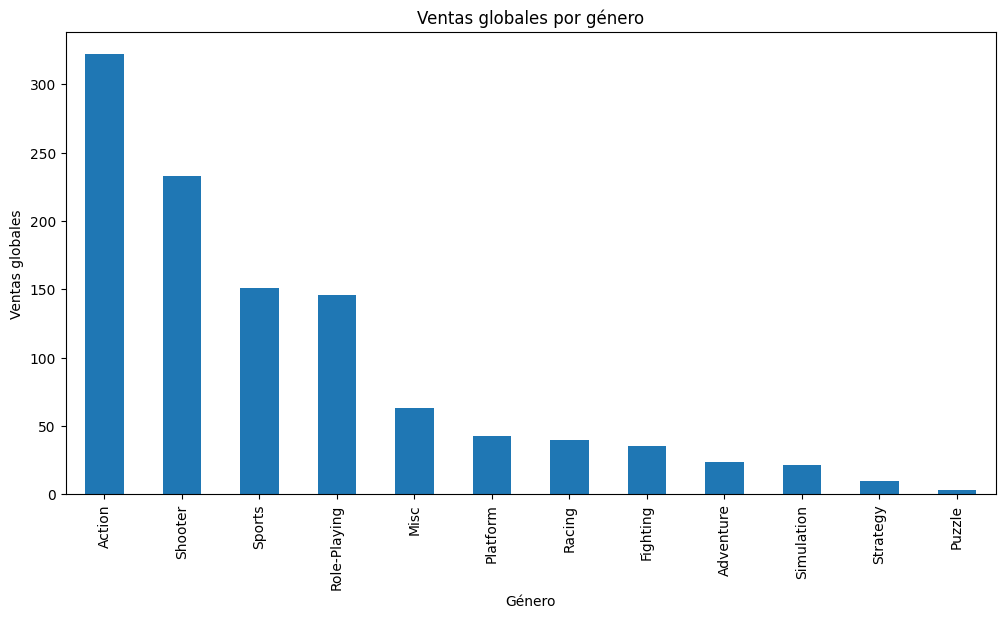

genre
Shooter         1.245882
Sports          0.703972
Platform        0.576081
Role-Playing    0.499623
Racing          0.469294
Fighting        0.441375
Action          0.420196
Misc            0.405290
Simulation      0.350968
Puzzle          0.186471
Strategy        0.180000
Adventure       0.096490
Name: total_sales, dtype: float64

In [20]:
genre_sales = recent_df.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
display(genre_sales)

plt.figure(figsize=(12,6))
genre_sales.plot(kind='bar')
plt.title('Ventas globales por género')
plt.xlabel('Género')
plt.ylabel('Ventas globales')
plt.show()


genre_mean_sales = recent_df.groupby('genre')['total_sales'].mean().sort_values(ascending=False)
display(genre_mean_sales)


Se puede observar que los generos mas vendidos son los generos que tienen mas movimiento constante, los cuales son la accion, los shooters y los juegos de deportes, lo que indica que el usuario promedio tiende a adquirir juegos con una dinamica rapida y cambiante. Los géneros con mayores ventas totales no siempre coinciden con los géneros con mayores ventas promedio por juego. Algunos géneros tienen muchos lanzamientos, mientras que otros, aunque con menos títulos, presentan un mejor rendimiento promedio.Esto se ve principalmente refejado con los juegos del genero platform, ya que el mismo se encuentra sexto respecto al total de ventas, mientras que en cuanto al promedio de ventas se encuentra tercero, otros generos siguen dicho patron como lo son Racing o Fighting, mientras que el genero mas vendido en su totalidad el cual es Action bajo al puesto 7, lo que sugiere una mayor eficiencia en juegos-creados/juegos-vendidos por lo que una estrategia sugerida seria enfocarse en los juegos que tienen un mayor rendimiento medio. Esto tambien puede indicar que cada genero tiene un publico objetivo distinto y el nivel de competitividad asimismo es distinto, por lo que a nivel de empresa se tienen dos opciones reales:
1. Hacer un videojuego Shooter/Action/Sports que se encuentran en un mercado altamente competitivo y tratar de ser diferencial, lo que implica un mayor riesgo pero una mayor recompensa.
2. Hacer un videojuego de un nicho especifico que tienen buena rentabilidad media debido a una competencia menor, siendo esto mas seguro pero con una recompensa potencial menor.


<div class="alert alert-block alert-success"> 
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Excelente analisis de ventas de juegos multiplataforma y por género. 

### Conclusión General - Paso 3: Análisis Exploratorio de Datos
##### Tendencias Temporales y Ciclo de Vida de Plataformas:

El análisis revela que la industria de videojuegos experimentó su pico de lanzamientos entre 2008-2009, coincidiendo con el éxito de la PS2. Sin embargo, desde 2013-2016 se observa una tendencia bajista generalizada en todas las plataformas, con PS4, XOne y 3DS como las únicas que mantienen actividad relevante, sugiriendo que están en la fase final de su ciclo de vida.

##### Patrones de Géneros y Estrategias de Mercado:

Se identificaron dos dinámicas de mercado claramente diferenciadas:

Géneros de "movimiento constante" (Action, Shooter, Sports): Dominan las ventas totales debido a su atractivo masivo y dinámicas rápidas que mantienen el engagement del usuario promedio
Géneros de nicho (Platform, Racing, Fighting): Muestran mayor eficiencia en la relación juegos-creados/ventas-generadas, con Platform destacando al ocupar el 6° lugar en ventas totales pero 3° en promedio por juego
Correlación entre Reseñas y Ventas:

El análisis de PS4 demostró una correlación positiva significativa entre critic_score y ventas (0.406), mientras que user_score mostró correlación negativa (-0.034). Esto indica que las reseñas profesionales son mejores predictores del éxito comercial que las opiniones de usuarios.

##### Diversidad de Distribución:

Se observó la coexistencia de juegos exclusivos de plataforma y multiplataforma, factor que influye significativamente en el potencial de ventas y debe considerarse en las estrategias de marketing.

##### Implicaciones Estratégicas para Ice:

El análisis sugiere dos estrategias empresariales viables:

Estrategia de alto riesgo/alta recompensa: Enfocarse en géneros competitivos (Action/Shooter/Sports) con gran potencial de mercado pero alta competencia
Estrategia de nicho eficiente: Apostar por géneros con menor competencia pero mayor rentabilidad promedio por título

#### Paso 4. Perfil de usuario por región

#### 4.1. Top 5 plataformas por región

In [21]:
for region in ['na_sales', 'eu_sales', 'jp_sales']:
    print(f'\nTop plataformas en {region}')
    print(recent_df.groupby('platform')[region].sum().sort_values(ascending=False).head(5))


Top plataformas en na_sales
platform
PS4     108.74
XOne     93.12
X360     81.66
PS3      63.50
3DS      38.20
Name: na_sales, dtype: float64

Top plataformas en eu_sales
platform
PS4     141.09
PS3      67.81
XOne     51.59
X360     42.52
3DS      30.96
Name: eu_sales, dtype: float64

Top plataformas en jp_sales
platform
3DS     67.81
PS3     23.35
PSV     18.59
PS4     15.96
WiiU    10.88
Name: jp_sales, dtype: float64


Se logra observar que en los mercados occidentales(Norte America y Europa) las plataformas mas predominantes son la PS4, la XOne y sus antecesoras las cuales son la PS3 y la X360, mientras que en el mercado Japones las plataformas mas predominantes son como numero uno la 3DS y numero dos la PS3 y como tercero la PSV. Esta diferencia en el mercado se puede deber al origen de cada una de las plataformas de consolas, asimismo influyendo esto en que tan populares son por región, como es el caso de la 3DS en el mercado Japones.

Por lo que a la hora de realizar campaña publicitaria se debe tener en cuenta la zona de origen y la preferencia del publico objetivo de dicha zona para enfocar la campaña a la plataforma con mayor preferencia regional.

#### 4.2. Top 5 géneros por región

In [22]:
for region in ['na_sales', 'eu_sales', 'jp_sales']:
    print(f'\nTop géneros en {region}')
    print(recent_df.groupby('genre')[region].sum().sort_values(ascending=False).head(5))


Top géneros en na_sales
genre
Action          126.05
Shooter         109.74
Sports           65.27
Role-Playing     46.40
Misc             27.49
Name: na_sales, dtype: float64

Top géneros en eu_sales
genre
Action          118.13
Shooter          87.86
Sports           60.52
Role-Playing     36.97
Racing           20.19
Name: eu_sales, dtype: float64

Top géneros en jp_sales
genre
Role-Playing    51.04
Action          40.49
Misc             9.20
Fighting         7.65
Shooter          6.61
Name: jp_sales, dtype: float64


Se logra observar como una constante el género action entre los 2 más populares para todas las regiones, por lo que este género es popular independientemente de la región, no obstante el género shooter es popular en Norte América y Europa, mientras que en Japón decae su popularidad significativamente. En Norte América y Europa el género más popular es Action, mientras que en Japón el género más popular es Role-Playing, lo que nos dice mucho sobre el comportamiento del mercado Japonés respecto al resto del mundo, ya que su nicho y público objetivo es distinto al de Norte América y Europa

#### 4.3. Impacto de ESRB por región

In [23]:
for region in ['na_sales', 'eu_sales', 'jp_sales']:
    print(f'\nVentas por clasificación ESRB en {region}')
    print(recent_df.groupby('rating')[region].sum().sort_values(ascending=False))


Ventas por clasificación ESRB en na_sales
rating
M       165.21
E        79.05
E10+     54.24
T        49.79
Name: na_sales, dtype: float64

Ventas por clasificación ESRB en eu_sales
rating
M       145.32
E        83.36
E10+     42.69
T        41.95
Name: eu_sales, dtype: float64

Ventas por clasificación ESRB en jp_sales
rating
T       20.59
E       15.14
M       14.11
E10+     5.89
Name: jp_sales, dtype: float64


Se observa que las ventas por clasificación ESRB en Europa y Norteamérica presentan patrones prácticamente idénticos, lo que sugiere similitudes en las regulaciones, el público objetivo y la cultura de consumo de videojuegos. En ambas regiones, la clasificación predominante es "M" (Mature), dirigida a personas mayores de 17 años, lo cual se correlaciona directamente con el género más popular en estas regiones: Acción, que típicamente recibe esta clasificación debido a su contenido.

En contraste, Japón muestra un comportamiento significativamente diferente, donde la clasificación "Teen" ocupa el primer lugar en ventas. Esta diferencia no solo refleja aspectos culturales distintivos, sino que también se alinea con el género más consumido en el mercado japonés: Role-Playing, que generalmente recibe clasificaciones menos restrictivas.

<div class="alert alert-block alert-success"> 
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Excelente! Como mencionas a lo largo de los perfiles regionales, Japón se diferencia de forma notoria frente a las demas regiones, mostrando la influencia cultural en el consumo y las tendencias del mercado. 

### Conclusión General - Paso 4: Perfil de usuario por region:

El análisis regional revela patrones de consumo claramente diferenciados que reflejan las preferencias culturales y demográficas de cada mercado. Los mercados occidentales (Norteamérica y Europa) muestran una notable homogeneidad en sus preferencias, dominados por plataformas de consola tradicionales (PS4, Xbox One y sus predecesoras), con una fuerte inclinación hacia géneros de acción y shooter, dirigidos principalmente a audiencias maduras (clasificación M).

En contraste, el mercado japonés presenta un perfil completamente distinto, caracterizado por la preferencia hacia plataformas portátiles (3DS como líder), una marcada preferencia por el género Role-Playing, y un público objetivo más joven (clasificación Teen predominante). Esta divergencia no solo refleja diferencias culturales profundas, sino también distintos hábitos de consumo y estilos de vida.

La correlación entre géneros y clasificaciones ESRB por región es particularmente reveladora: mientras que en Occidente la popularidad de los juegos de acción se alinea con las clasificaciones para adultos, en Japón la preferencia por RPGs se corresponde con clasificaciones más accesibles para adolescentes.

Estos hallazgos sugieren la necesidad de estrategias de marketing y desarrollo de productos altamente regionalizadas, reconociendo que no existe un enfoque único que funcione globalmente en la industria de los videojuegos.

### Paso 5: Prueba de las hipotesis

#### 5.1 Hipótesis 1

Las calificaciones promedio de usuarios para Xbox One y PC son las mismas

##### Formulación
###### H0: la media de user_score en Xbox One es igual a la media de user_score en PC.

###### H1: la  media de user_score en Xbox One es distinta a la media de user_score en PC.

In [24]:
alpha= 0.05
xone_scores = recent_df[(recent_df['platform'] == 'XOne') & (~recent_df['user_score'].isna())]['user_score']
pc_scores = recent_df[(recent_df['platform'] == 'PC') & (~recent_df['user_score'].isna())]['user_score']

results1 = stats.ttest_ind(xone_scores, pc_scores, equal_var=False)

print('p-value:', results1.pvalue)

if results1.pvalue < alpha:
    print("Se rechaza la hipótesis nula")
else:
    print("No se rechaza la hipótesis nula")

p-value: 0.14759594013430463
No se rechaza la hipótesis nula


Este resultado indica que la media entre ambos es igual

#### 5.2 Hipótesis 2

Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

##### Formulación

###### H0: La media de calificaciones del genero de accion y deportes son iguales.

###### H1: La media de calificaciones del genero de accion y deportes son distintas.

In [25]:
alpha_2=0.05
action_scores = recent_df[(recent_df['genre'] == 'Action') & (~recent_df['user_score'].isna())]['user_score']
sports_scores = recent_df[(recent_df['genre'] == 'Sports') & (~recent_df['user_score'].isna())]['user_score']

results2 = stats.ttest_ind(action_scores, sports_scores, equal_var=False)

print('p-value:', results2.pvalue)

if results2.pvalue < alpha_2:
    print("Se rechaza la hipótesis nula")
else:
    print("No se rechaza la hipótesis nula")

p-value: 1.4460039700704315e-20
Se rechaza la hipótesis nula


Este resultado indica que ambas medias son distintas.

<div class="alert alert-block alert-success"> 
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Hiciste un excelente trabajo con las pruebas de hipótesis. Tu eleccion de los tipos de prueba y los niveles de significancia es muy acertada. Además, las justificaciones que proporcionas para interpretar los resultados le dan un completo desarrollo al trabajo. Excelente

### Paso 6: Conclusiones generales del proyecto.

### Hallazgos Principales
#### 1. Evolución Temporal de la Industria

El análisis temporal reveló que la industria de videojuegos experimentó su época dorada entre 2008-2009, coincidiendo con el éxito masivo de la PS2. Sin embargo, desde 2013-2016 se observa una tendencia bajista generalizada, con solo PS4, Xbox One y 3DS manteniendo actividad relevante, indicando que estas plataformas están en la fase final de su ciclo de vida.

#### 2. Segmentación Regional Marcada

Se identificaron dos mercados claramente diferenciados:

Mercados Occidentales (NA/EU): Preferencia por consolas tradicionales (PS4, Xbox One), géneros de acción/shooter, y audiencias maduras (clasificación M)

Mercado Japonés: Dominio de plataformas portátiles (3DS), preferencia por Role-Playing, y público más joven (clasificación Teen)

#### 3. Estrategias de Género Diferenciadas

El análisis reveló dos enfoques estratégicos viables:

Géneros masivos: Action, Shooter, Sports dominan ventas totales pero enfrentan alta competencia

Géneros de nicho: Platform, Racing, Fighting muestran mayor eficiencia por título lanzado


#### 4. Validación Estadística

Las pruebas de hipótesis confirmaron:

Las calificaciones de usuarios entre Xbox One y PC son estadísticamente iguales (p=0.147)

Las calificaciones entre géneros Action y Sports son significativamente diferentes (p=1.44e-20)


##### Recomendaciones Estratégicas para Ice


#####  Segmentación Regional

Desarrollar campañas publicitarias específicas por región

Para NA/EU: Enfocarse en géneros de acción con clasificación M

Para Japón: Priorizar RPGs con clasificación Teen en plataformas portátiles


##### - Predicción de Éxito

Utilizar critic_score como predictor principal de ventas (correlación 0.406)

Las reseñas de usuarios no son indicadores confiables del éxito comercial

##### - Estrategia de Plataformas

Concentrar esfuerzos en PS4, Xbox One y 3DS para el período 2017

Prepararse para el próximo ciclo de consolas (2-3 años)
##### - Enfoque de Géneros


Estrategia conservadora: Apostar por géneros de nicho con alta eficiencia

Estrategia agresiva: Competir en géneros masivos con diferenciación clara

#### Conclusión Final

El análisis demuestra que el éxito en la industria de videojuegos requiere una comprensión profunda de las diferencias regionales y una estrategia adaptada al ciclo de vida de las plataformas. La correlación entre reseñas profesionales y ventas, junto con los patrones regionales identificados, proporciona a Ice las herramientas necesarias para tomar decisiones informadas sobre inversión en proyectos y estrategias de marketing para 2017.

<div class="alert alert-block alert-success"> 
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Has hecho un excelente trabajo. Tus conclusiones son detalladas y muy utiles. Me gustan las recomendaciones estratégicas que propones, ya que recopilas cada uno de los resultados obtenidos en forma de propuesta de acción, este es justo el objetivo que tenemos como científicos de datos en este camino. Sigue así!
</div>